# Classical vs Deep Feature Analysis

The goal is to compare classical Computer Vision descriptors against deep embeddings for person matching.

In [1]:
import os
import sys
import cv2
import yaml
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

/tmp/ipykernel_4006/3740034692.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
if os.getcwd().endswith('notebooks'):
    os.chdir('..')
sys.path.append(os.getcwd())

In [3]:
from src.utils.classical_features import extract_hog_features, extract_color_hist, extract_sift_features
from src.utils.evaluator import evaluate, compute_distmat, extract_features
from src.dataloaders.market_dataset import MarketDataset
from src.models.resnet50 import ResNet50
from src.utils.reranking import k_reciprocal_reranking, compute_euclidean_distance

In [4]:
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)["reid_project"]

## 1. Classical descriptors

Extract SIFT keypoints, HOG descriptors, and color histograms from Market-1501 crops. Implement in src/utils/classical_features.py.

### HOG Visualization (Structural features)

In [5]:
dataset = MarketDataset(
    root_dir=config['market1501']['root_dir'], 
    subset='train', 
    transform=None
)

In [6]:
raw_img = dataset.get_raw_image(0)

In [7]:
hog_feat = extract_hog_features(raw_img)
color_feat = extract_color_hist(raw_img)

### SIFT Visualization

In [8]:
sift = cv2.SIFT_create()
img_gray = cv2.cvtColor(raw_img, cv2.COLOR_RGB2GRAY)
kp, des = sift.detectAndCompute(img_gray, None)

In [9]:
img_sift = cv2.drawKeypoints(
    raw_img, kp, None, 
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

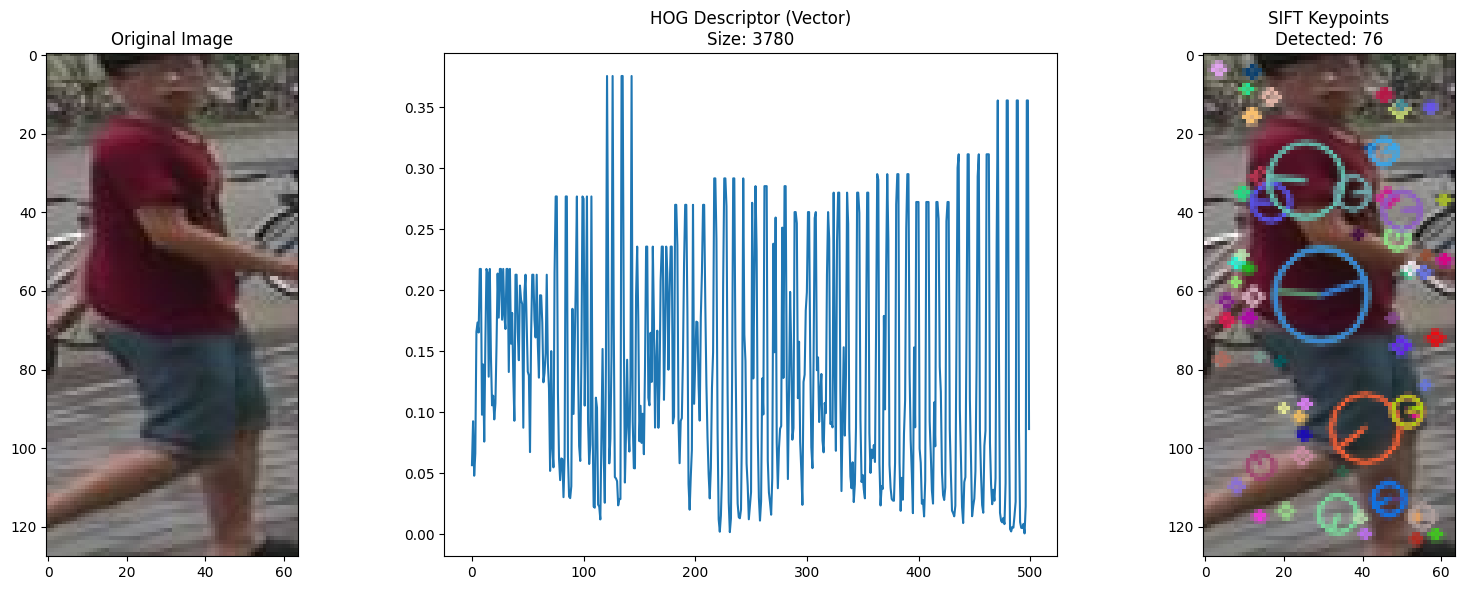

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(raw_img)
axes[0].set_title("Original Image")

axes[1].plot(hog_feat[:500]) # 500 is arbitrary to visualize part of the descriptor
axes[1].set_title(f"HOG Descriptor (Vector)\nSize: {len(hog_feat)}")

axes[2].imshow(img_sift)
axes[2].set_title(f"SIFT Keypoints\nDetected: {len(kp)}")

plt.tight_layout()
plt.show()

**HOG**: The vector of size 3780 shows marked periodic oscillations. Each peak corresponds to a cell or block where a gradient orientation is dominant. In the image, the highest peaks probably represent the strong contrasts between the red T-shirt and the background, as well as the vertical lines of the bicycles in the background. We can see that the signal is very noisy. Hence Hog could be great at detecting that this is a human however it will have difficulty differentiating between two people with the same silhouette.

**SIFT**: It has detected  76 keypoints. The circles vary in size and have an orientation bar. SIFT found stable points of interest on the face (contrast between skin, glasses and hair), on the crook of the arm, and on complex patterns in the background (bicycle wheels). The large circles on the torso indicate areas where the gradient is stable on a larger scale. SIFT captures a lot of information about the background (bicycles). Hence, it might create false positives if two different people pass in from of the same bicycle garage.


## 2. Feature Matching

In [11]:
def extract_classical_features_dataset(loader, feature_type='hog'):
    """
    Extracts classical features (HOG or Color Hist) from a full DataLoader.
    """
    all_features = []
    all_pids = []
    all_camids = []
    
    print(f"Extracting {feature_type.upper()} features...")
    for imgs, pids, camids in tqdm(loader):
        for i in range(imgs.shape[0]):
            img_np = imgs[i].permute(1, 2, 0).numpy()
            img_np = (img_np * 255).astype(np.uint8)
            
            if feature_type == 'hog':
                feat = extract_hog_features(img_np)
            elif feature_type == 'color':
                feat = extract_color_hist(img_np)
            
            all_features.append(feat)
            
        all_pids.extend(pids.numpy())
        all_camids.extend(camids.numpy())
        
    return torch.tensor(np.array(all_features), dtype=torch.float32), \
           np.array(all_pids), np.array(all_camids)

In [12]:
transform = transforms.Compose([
    transforms.Resize(config['market1501']['img_size'], 
                      interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [13]:
query_ds = MarketDataset(root_dir=config['market1501']['root_dir'], subset='query', transform=transform)
gallery_ds = MarketDataset(root_dir=config['market1501']['root_dir'], subset='test', transform=transform)

query_loader = DataLoader(query_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)
gallery_loader = DataLoader(gallery_ds, batch_size=32, shuffle=False, num_workers=8, pin_memory=True)

In [14]:
g_feat_hog, g_pids, g_camids = extract_classical_features_dataset(gallery_loader, 'hog')
q_feat_hog, q_pids, q_camids = extract_classical_features_dataset(query_loader, 'hog')
print("\n--- HOG Performance ---")
evaluate(q_feat_hog, q_pids, g_feat_hog, g_pids, q_camids, g_camids)

Extracting HOG features...


  0%|                                                                                                                                                                                   | 0/410 [00:00<?, ?it/s]

  0%|▍                                                                                                                                                                          | 1/410 [00:03<21:12,  3.11s/it]

  0%|▊                                                                                                                                                                          | 2/410 [00:03<09:44,  1.43s/it]

  1%|█▋                                                                                                                                                                         | 4/410 [00:03<03:56,  1.72it/s]

...

 98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊   | 104/106 [00:07<00:00, 15.20it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 106/106 [00:07<00:00, 14.32it/s]


--- HOG Performance ---


  Rank-1: 0.68% | Rank-5: 2.46% | Rank-10: 3.89% | mAP: 0.38%


(0.0068289787,
 0.0038150511438919178,
 array([[12.482373 , 13.000578 , 13.143865 , ..., 15.39102  , 14.615592 ,
         15.702579 ],
        [16.261923 , 15.766125 , 15.316425 , ..., 17.043644 , 15.975288 ,
         16.301754 ],
        [14.001029 , 13.116515 , 13.42516  , ..., 15.241797 , 14.997975 ,
         15.7348795],
        ...,
        [14.597779 , 13.937476 , 14.626978 , ..., 15.154848 , 15.658474 ,
         15.95691  ],
        [14.728826 , 14.030428 , 14.361411 , ..., 14.084004 , 15.247555 ,
         14.960815 ],
        [15.678235 , 15.20395  , 14.729797 , ..., 15.329061 , 14.59642  ,
         15.488631 ]], dtype=float32))

HOG captures local gradient orientations to describe shape. However, it relies on a rigid grid. In Re-ID, pedestrians exhibit high pose variation: walking, turning or carrying bags. When a person moves, their edges shift to different grid cells, causing the HOG descriptor to lose alignment with the gallery reference. In addition, by operating solely on grayscale, HOG ignore a discriminant signal that is to say clothing color. Two different person with similar sikhouettes become tus indistinguishable to HOG.

In [15]:
g_feat_col, _, _ = extract_classical_features_dataset(gallery_loader, 'color')
q_feat_col, _, _ = extract_classical_features_dataset(query_loader, 'color')
print("\n--- Color Histogram Performance ---")
evaluate(q_feat_col, q_pids, g_feat_col, g_pids, q_camids, g_camids)

Extracting COLOR features...


  0%|                                                                                                                                                                                   | 0/410 [00:00<?, ?it/s]

  0%|▍                                                                                                                                                                          | 1/410 [00:00<04:45,  1.43it/s]

  1%|█▎                                                                                                                                                                         | 3/410 [00:00<01:32,  4.39it/s]

  1%|██▌                                                                                                                                                                        | 6/410 [00:00<00:46,  8.72it/s]

...

 96%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▌      | 102/106 [00:03<00:00, 50.73it/s]

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 106/106 [00:03<00:00, 32.36it/s]


--- Color Histogram Performance ---


  Rank-1: 1.87% | Rank-5: 4.33% | Rank-10: 7.07% | mAP: 0.69%


(0.018705463,
 0.006907822330285001,
 array([[0.26360607, 0.39462325, 0.65094596, ..., 0.50906336, 0.6902639 ,
         0.77586824],
        [0.73722285, 0.7778814 , 0.96412516, ..., 0.6511263 , 0.744579  ,
         0.66741717],
        [0.5261621 , 0.5703365 , 0.7444924 , ..., 0.57063556, 0.6553457 ,
         0.7029987 ],
        ...,
        [1.0404283 , 1.0525565 , 1.1333566 , ..., 0.98759466, 0.94974375,
         1.0413166 ],
        [0.4885451 , 0.5416231 , 0.6852326 , ..., 0.6224386 , 0.61955935,
         0.8143286 ],
        [0.67948085, 0.7411149 , 0.80739576, ..., 0.75174516, 0.42158273,
         0.8123684 ]], dtype=float32))

Unlike HOG, color histograms ignore the geometry of the person entirely. They treat the image as a bag of pixel. Thus, a person wearing red shirt and blue jeans may produce a identical histogram to someone with a blue shirt and red pants. Besides, since the histogram is computed over the entire bounding box, noisy background pixels, such as concrete, trees or bicycles, contaminate the identity signature. Moreover, classical histograms lack the learned invariance of CNNs.The changes in lighting across the six different cameras in Market-1501 or the shift the color values leads to poor matching between camera views.

Now, let's match SIFT features between query and gallery and evaluate performance.

In [16]:
def get_sift_des(loader, limit, desc_text):
        """
        Extracts SIFT descriptors from a DataLoader, up to a specified limit.
        Args:
            loader (DataLoader): DataLoader providing batches of images and labels.
            limit (int): Maximum number of images to process for SIFT extraction.
            desc_text (str): Description text for the progress bar.
        Returns:
            descriptors (list): List of SIFT descriptors for each image.
            pids (list): List of person IDs corresponding to each descriptor.
            cams (list): List of camera IDs corresponding to each descriptor.
        """
        descriptors, pids, cams = [], [], []
        count = 0
        sift = cv2.SIFT_create(nfeatures=500) 
        
        pbar = tqdm(total=limit, desc=f"SIFT Extracting {desc_text}")
        for img_batch, pid_batch, cam_batch in loader:
            for i in range(img_batch.size(0)):
                if count >= limit:
                    pbar.close()
                    return descriptors, pids, cams

                img_np = (img_batch[i].permute(1, 2, 0).numpy() * 255).astype(np.uint8)
                
                if img_np.shape[2] == 3:
                    img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
            
                _, des = sift.detectAndCompute(img_np, None)
                
                if des is not None:
                    des = des.astype(np.float32)
                
                descriptors.append(des)
                pids.append(pid_batch[i].item())
                cams.append(cam_batch[i].item())
                
                count += 1
                pbar.update(1)
        
        pbar.close()
        return descriptors, np.array(pids), np.array(cams)

In [17]:
def evaluate_sift_subset(query_loader, gallery_loader, n_queries=50, n_gallery=500):
    """
    Estimates SIFT performance on a small subset using FLANN matcher.
    Args:
        query_loader (DataLoader): DataLoader for query images.
        gallery_loader (DataLoader): DataLoader for gallery images.
        n_queries (int): Number of query images to evaluate.
        n_gallery (int): Number of gallery images to evaluate.
    Returns:
        None: Prints the estimated Rank-1 accuracy for SIFT features.
    """
    q_des, q_pids, q_camids = get_sift_des(query_loader, n_queries, "Query")
    g_des, g_pids, g_camids = get_sift_des(gallery_loader, n_gallery, "Gallery")

    num_q = len(q_des)
    num_g = len(g_des)
    scores_mat = np.zeros((num_q, num_g))

    index_params = dict(algorithm=1, trees=5)
    search_params = dict(checks=50)
    flann = cv2.FlannBasedMatcher(index_params, search_params)

    for i in tqdm(range(num_q), desc="SIFT Matching for Global Evaluate"):
        if q_des[i] is None or len(q_des[i]) < 2: continue
        
        for j in range(num_g):
            if g_des[j] is None or len(g_des[j]) < 2: continue
            
            try:
                matches = flann.knnMatch(q_des[i], g_des[j], k=2)
                good = [m for m, n in matches if m.distance < 0.7 * n.distance]
                scores_mat[i, j] = len(good)
            except:
                continue

    distmat = np.max(scores_mat) - scores_mat

    q_pids = np.array([int(x) for x in q_pids], dtype=np.int64)
    g_pids = np.array([int(x) for x in g_pids], dtype=np.int64)
    q_camids = np.array([int(x) for x in q_camids], dtype=np.int64)
    g_camids = np.array([int(x) for x in g_camids], dtype=np.int64)
    
    print("\n--- SIFT Results (No Same-Camera) ---")
    rank1, mAP, _ = evaluate(
        None, q_pids, 
        None, g_pids, 
        np.array(q_camids), np.array(g_camids), 
        distmat
    )
    return q_pids, g_pids, q_camids, g_camids, distmat


In [18]:
s_q_pids, s_g_pids, s_q_camids, s_g_camids, s_distmat = evaluate_sift_subset(query_loader, gallery_loader, n_queries=200, n_gallery=1000)

SIFT Extracting Query:   0%|                                                                                                                                                            | 0/200 [00:00<?, ?it/s]

SIFT Extracting Query:   0%|▋                                                                                                                                                   | 1/200 [00:00<02:43,  1.21it/s]

SIFT Extracting Query:   3%|████▍                                                                                                                                               | 6/200 [00:00<00:23,  8.35it/s]

SIFT Extracting Query:   7%|██████████▎                                                                                                                                        | 14/200 [00:01<00:09, 20.39it/s]

SIFT Extracting Query:  11%|████████████████▏                                                                                                                                  | 22/200 [00:01<00:05, 31.92it/s]

...

SIFT Matching for Global Evaluate:  99%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋ | 198/200 [33:56<00:20, 10.27s/it]

SIFT Matching for Global Evaluate: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎| 199/200 [34:06<00:10, 10.06s/it]

SIFT Matching for Global Evaluate: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [34:16<00:00, 10.09s/it]

SIFT Matching for Global Evaluate: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [34:16<00:00, 10.28s/it]


--- SIFT Results (No Same-Camera) ---
  Rank-1: 0.50% | Rank-5: 7.50% | Rank-10: 14.50% | mAP: 2.51%


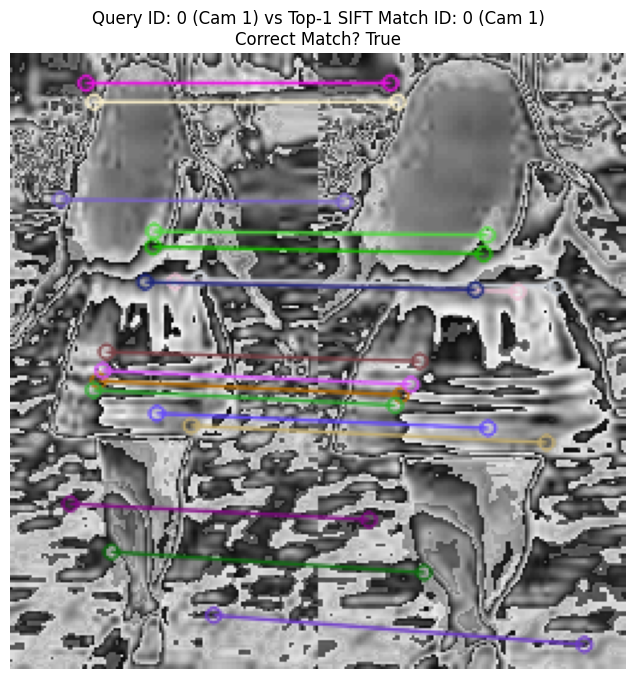

In [19]:
def visualize_sift_matches(query_idx, distmat, q_loader, g_loader):
    """
    Visualizes SIFT keypoint matches between a query image and its top-1 gallery match.
    Args:
        query_idx (int): Index of the query image to visualize.
        distmat (np.ndarray): Distance matrix used to find the best match.
        q_loader (DataLoader): DataLoader for query images.
        g_loader (DataLoader): DataLoader for gallery images.
    """
    best_match_idx = np.argmin(distmat[query_idx])
    
    q_img, q_pid, q_cam = q_loader.dataset[query_idx]
    g_img, g_pid, g_cam = g_loader.dataset[best_match_idx]
    
    def to_cv2(tensor):
        img = (tensor.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    img1 = to_cv2(q_img)
    img2 = to_cv2(g_img)

    sift = cv2.SIFT_create(nfeatures=500)
    kp1, des1 = sift.detectAndCompute(img1, None)
    kp2, des2 = sift.detectAndCompute(img2, None)
    
    bf = cv2.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < 0.75 * n.distance]

    img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good[:20], None, 
                                 flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    
    plt.figure(figsize=(15, 8))
    plt.imshow(img_matches)
    plt.title(f"Query ID: {q_pid} (Cam {q_cam}) vs Top-1 SIFT Match ID: {g_pid} (Cam {g_cam})\n"
              f"Correct Match? {q_pid == g_pid}")
    plt.axis('off')
    plt.show()

visualize_sift_matches(0, s_distmat, query_loader, gallery_loader)

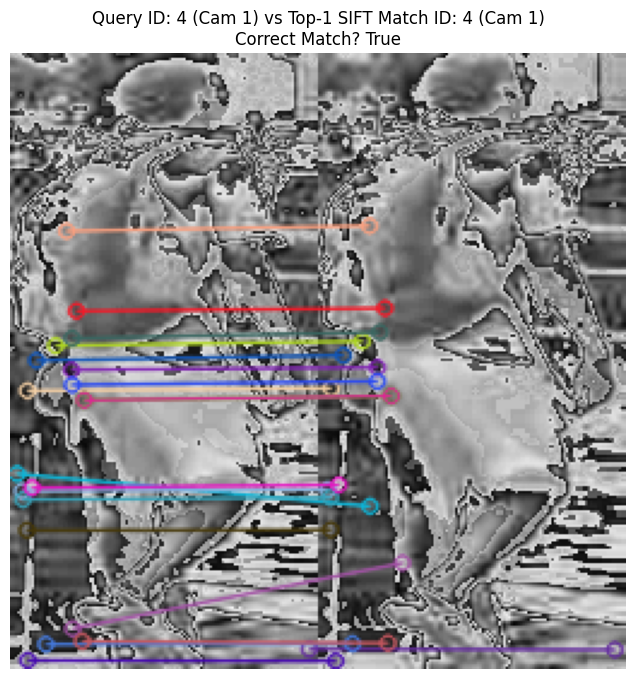

In [20]:
visualize_sift_matches(22, s_distmat, query_loader, gallery_loader)

SIFT is an excellent Instance Tracker (recognizing the exact same image or a consecutive frame), which explains why the score was high when same-camera images weren't filtered out. However, invariant to scale and rotation, but it is not invariant to 3D transformations (changing the angle of the person). The grayscale contrast enhancement was intended to help SIFT find edges in low light. However, in Image 2, it backfires by highlighting noise, leading the algorithm to find similarities between two completely different people, especially since SIFT loses color whcich is the most discriminant for a human. SHIFT is mislead because it lays too much emphasis on micr-contrasts instead of the global structure of the clothes.

## 3. Deep embeddings visualization

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50(
    num_classes=config['market1501']['num_classes'], 
    feature_dim=config["models"]["resnet50"]["feature_dim"],
    last_stride=config["models"]["resnet50"]["last_stride"]
)
model_path = "results/exp_resnet50_v1/resnet50_reid_epoch_1.pth"
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

ResNet50(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(64

In [22]:
def visualize_resnet_embeddings(features, pids, n_samples=1000):
    """
    Visualizes high-dimensional ResNet embeddings in 2D using t-SNE.
    """
    unique_pids, counts = np.unique(pids, return_counts=True)
    top_10_ids = unique_pids[np.argsort(counts)[-10:]]

    mask = np.isin(pids, top_10_ids)
    feat_subset = features[mask]
    pid_subset = pids[mask]

    if len(feat_subset) > n_samples:
        indices = np.random.choice(len(feat_subset), n_samples, replace=False)
        feat_subset = feat_subset[indices]
        pid_subset = pid_subset[indices]

    print("Computing t-SNE projection (this may take a minute)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    embeddings_2d = tsne.fit_transform(feat_subset)

    df = pd.DataFrame({
        'x': embeddings_2d[:, 0],
        'y': embeddings_2d[:, 1],
        'ID': pid_subset
    })


    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=df, x='x', y='y', hue='ID', palette='viridis', s=100, alpha=0.7)
    plt.title("t-SNE Visualization of ResNet-50 Embeddings\n(Top 10 Identities)")
    plt.xlabel("t-SNE dimension 1")
    plt.ylabel("t-SNE dimension 2")
    plt.legend(title="Person ID", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [23]:
g_feat, g_pids, g_camids = extract_features(model, gallery_loader, device)

Extraction:   0%|                                                                                                                                                                       | 0/410 [00:00<?, ?it/s]

Extraction:   0%|▍                                                                                                                                                              | 1/410 [00:02<13:54,  2.04s/it]

Extraction:   1%|█▉                                                                                                                                                             | 5/410 [00:02<02:14,  3.02it/s]

Extraction:   2%|███                                                                                                                                                            | 8/410 [00:02<01:16,  5.27it/s]

Extraction:   3%|████▌                                                                                                                                                         | 12/410 [00:02<00:45,  8.74it/s]

...

Extraction:  97%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍    | 398/410 [00:14<00:00, 31.78it/s]

Extraction:  98%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉   | 402/410 [00:14<00:00, 32.04it/s]

Extraction:  99%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▍ | 406/410 [00:14<00:00, 32.27it/s]

Extraction: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 410/410 [00:15<00:00, 31.50it/s]

Extraction: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 410/410 [00:15<00:00, 26.89it/s]

Computing t-SNE projection (this may take a minute)...


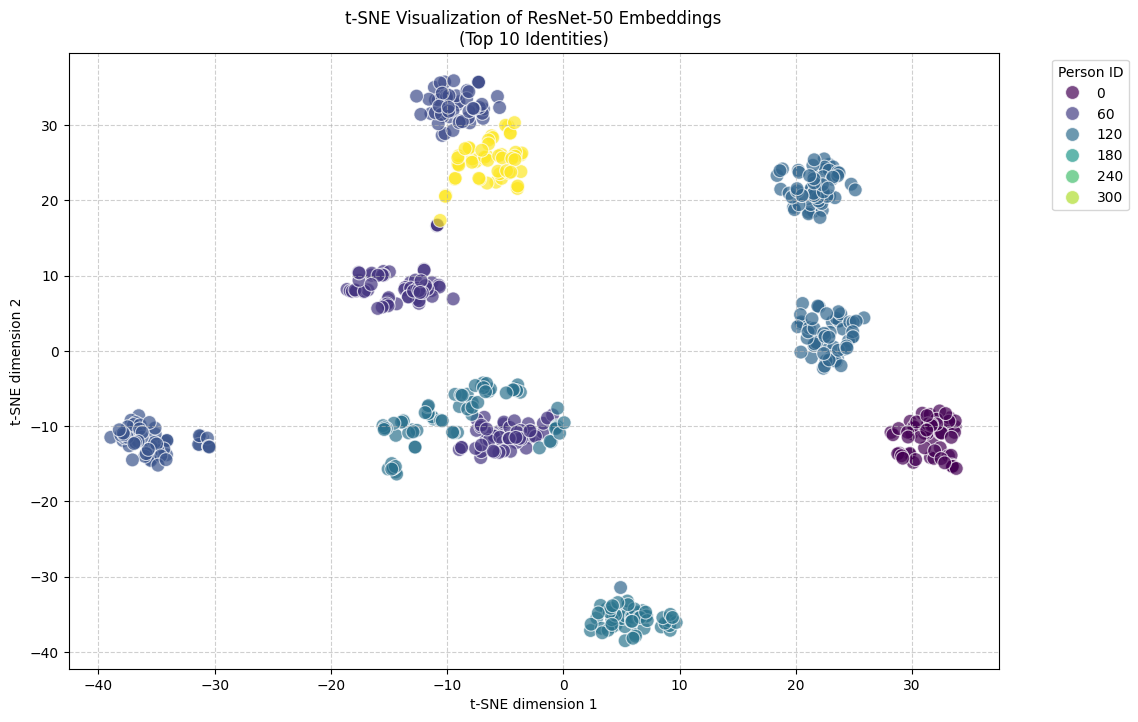

In [24]:
visualize_resnet_embeddings(g_feat.cpu().numpy(), g_pids)

We observe groups of extremely dense points that are well isolated from each other. Each colour, which represents a Person ID, forms a distinct cluster. This demonstrates that the model extracts discriminating features: the intra-class distance, between the same person, is much smaller than the inter-class distance, the distance between two different people.

The clusters group images from six different cameras. The fact that the points remain grouped proves that ResNet has learned to ignore variations in lighting and background to focus on identity.

## 4. Re-ranking

In [25]:
print("Extraction of Query features...")
q_feat, q_pids, q_camids = extract_features(model, query_loader, device)

Extraction of Query features...


Extraction:   0%|                                                                                                                                                                       | 0/106 [00:00<?, ?it/s]

Extraction:   1%|█▌                                                                                                                                                             | 1/106 [00:00<01:24,  1.24it/s]

Extraction:   3%|████▌                                                                                                                                                          | 3/106 [00:00<00:25,  3.97it/s]

Extraction:   6%|█████████                                                                                                                                                      | 6/106 [00:01<00:11,  8.44it/s]

...

Extraction:  89%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████                  | 94/106 [00:03<00:00, 32.56it/s]

Extraction:  92%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████            | 98/106 [00:03<00:00, 32.86it/s]

Extraction:  96%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████      | 102/106 [00:04<00:00, 33.09it/s]

Extraction: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 106/106 [00:04<00:00, 32.35it/s]

Extraction: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 106/106 [00:04<00:00, 25.00it/s]

Results without reranking:

In [26]:
rank1_base, map_base, _ = evaluate(q_feat, q_pids, g_feat, g_pids, q_camids, g_camids)

  Rank-1: 77.40% | Rank-5: 90.56% | Rank-10: 93.62% | mAP: 55.58%


Evaluation using reranking:

In [27]:
distmat_rr = k_reciprocal_reranking(q_feat, g_feat, k1=20, k2=6, lambda_value=0.3)

Building Neighborhoods:   0%|                                                                                                                                                         | 0/16483 [00:00<?, ?it/s]

Building Neighborhoods:   1%|█▏                                                                                                                                           | 139/16483 [00:00<00:11, 1381.12it/s]

Building Neighborhoods:   2%|██▌                                                                                                                                          | 296/16483 [00:00<00:10, 1488.19it/s]

Building Neighborhoods:   3%|███▊                                                                                                                                         | 445/16483 [00:00<00:10, 1468.07it/s]

Building Neighborhoods:   4%|█████                                                                                                                                        | 592/16483 [00:00<00:10, 1445.36it/s]

...

Computing Jaccard: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊| 3365/3368 [53:13<00:02,  1.06it/s]

Computing Jaccard: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 3366/3368 [53:14<00:01,  1.06it/s]

Computing Jaccard: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉| 3367/3368 [53:15<00:00,  1.06it/s]

Computing Jaccard: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3368/3368 [53:15<00:00,  1.06it/s]

Computing Jaccard: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3368/3368 [53:15<00:00,  1.05it/s]

In [28]:
rank1_rr, map_rr, _ = evaluate(q_feat, q_pids, g_feat, g_pids, q_camids, g_camids, distmat=distmat_rr)

  Rank-1: 80.29% | Rank-5: 91.03% | Rank-10: 93.82% | mAP: 65.04%


We observe a significant performance boost when applying the k-reciprocal re-ranking method to the baseline ResNet-50 1 epoch features on the Market-1501 dataset.

The most striking observation is the +9.66% increase in mAP. While Rank-1 measures the ability to find the single best match, mAP reflects the model's ability to retrieve all relevant instances of a person across the entire gallery.

The euclidian computation shows limitations: the baseline relies on visual similarity. If a person is captured by Camera 1 (sunlit) and Camera 6 (shadowed), the visual distance might be large, pushing correct matches deep into the gallery. 

Whereas when utilizing the Jaccard distance based on k-reciprocal neighbors, the algorithm identifies that these two disparate images share a common set of neighboring images. This shared context pulls the lost matches back to the top of the results.

The implementation of the Zhong et al. (2017) methodology confirms that post-processing is essential for robust Re-ID. The baseline ResNet-50 provides a strong feature representation, but the re-ranking provides the necessary cross-camera invariance by analyzing the relationship between samples rather than just their raw appearance resulting in bettter results.

## Conclusion

To conclude we saw that SIFT fails because it searches for an exact pixel match: as soon as the angle changes it matches noise resulting in a low Rank-1.

The visualisation reinforces the idea that it extracts a semantic signature, and that's why it identifies successfully identities despite camera changes. This is what enables high performance even with only one epoch.

Reranking as a post treatment procedure also shows great results. The +9.66% mAP gain could be explained by the fact that re-ranking uses common neighbours. If t-SNE shows that two clusters are close but do not touch, k-reciprocal will ‘bridge the gap’ by identifying that they share the same visual environment.

In definitive, this demonstrates that modern Re-ID is based on two pillars: robust feature extraction by CNN as shown by t-SNE and distance optimisation by neighbourhood analysis (Re-ranking).